<a href="https://colab.research.google.com/github/Fettadjedour/prediction-departs-rh/blob/main/Projet_rh_prediction_departs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")
sns.set_palette("husl")

print("✅ Toutes les bibliothèques sont chargées !")

✅ Toutes les bibliothèques sont chargées !


In [ ]:
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/HR_comma_sep.csv"

In [ ]:
import pandas as pd
import numpy as np

# On génère le dataset directement — plus besoin d'URL !
np.random.seed(42)
n = 1470

departements = ['sales', 'technical', 'support', 'IT', 'hr', 'accounting', 'marketing', 'RandD', 'management', 'product_mng']
salaires = ['low', 'medium', 'high']

df = pd.DataFrame({
    'satisfaction':          np.random.uniform(0.1, 1.0, n).round(2),
    'derniere_evaluation':   np.random.uniform(0.4, 1.0, n).round(2),
    'nb_projets':            np.random.randint(2, 8, n),
    'heures_mois':           np.random.randint(96, 310, n),
    'anciennete':            np.random.randint(1, 11, n),
    'accident_travail':      np.random.randint(0, 2, n),
    'promotion_5ans':        np.random.randint(0, 2, n),
    'departement':           np.random.choice(departements, n),
    'salaire':               np.random.choice(salaires, n),
})

# On calcule les départs de façon réaliste
# (les insatisfaits surchargés et mal payés partent plus)
prob_depart = (
    (1 - df['satisfaction']) * 0.5 +
    (df['heures_mois'] / 310) * 0.3 +
    (df['salaire'] == 'low').astype(int) * 0.2
)
df['depart'] = (prob_depart > np.random.uniform(0, 1, n)).astype(int)

print("✅ Dataset créé avec succès !")
print(f"📊 {df.shape[0]} employés, {df.shape[1]} colonnes")
print(f"🚪 Taux de départ : {df['depart'].mean()*100:.1f}%")
print(df.head())

✅ Dataset créé avec succès !
📊 1470 employés, 10 colonnes
🚪 Taux de départ : 48.9%
   satisfaction  derniere_evaluation  nb_projets  heures_mois  anciennete  \
0          0.44                 0.74           2          153           6   
1          0.96                 0.84           2          189           8   
2          0.76                 0.93           5          214          10   
3          0.64                 0.64           5          222           1   
4          0.24                 0.60           2          264           4   

   accident_travail  promotion_5ans departement salaire  depart  
0                 1               0          IT    high       1  
1                 0               1     support  medium       0  
2                 0               1          hr    high       0  
3                 0               0          IT  medium       0  
4                 1               1       sales  medium       1  


In [ ]:
# --- Renommer les colonnes en français pour mieux comprendre ---
df.columns = [
    'satisfaction', 'derniere_evaluation', 'nbr_projets',
    'heures_mois', 'anciennete', 'accident_travail',
    'depart', 'promotion_5ans', 'departement', 'salaire'
]
print("✅ Dataset chargé avec succès !")
print(f"📊 Taille du dataset : {df.shape[0]} employés, {df.shape[1]} colonnes")

✅ Dataset chargé avec succès !
📊 Taille du dataset : 1470 employés, 10 colonnes


In [ ]:
"ÉTAPE 3 — Explorer les données (EDA)"
# Avant de coder quoi que ce soit, il faut COMPRENDRE les données

# --- Vue d'ensemble ---
print("\n📋 APERÇU DES DONNÉES :")
print(df.head())

print("\n📐 TYPES DE COLONNES :")
print(df.dtypes)

print("\n🔍 STATISTIQUES DESCRIPTIVES :")
print(df.describe())

print("\n❓ VALEURS MANQUANTES :")
print(df.isnull().sum())



📋 APERÇU DES DONNÉES :
   satisfaction  derniere_evaluation  nbr_projets  heures_mois  anciennete  \
0          0.44                 0.74            2          153           6   
1          0.96                 0.84            2          189           8   
2          0.76                 0.93            5          214          10   
3          0.64                 0.64            5          222           1   
4          0.24                 0.60            2          264           4   

   accident_travail  depart promotion_5ans departement  salaire  
0                 1       0             IT        high        1  
1                 0       1        support      medium        0  
2                 0       1             hr        high        0  
3                 0       0             IT      medium        0  
4                 1       1          sales      medium        1  

📐 TYPES DE COLONNES :
satisfaction           float64
derniere_evaluation    float64
nbr_projets              i

In [ ]:
# --- Quelle proportion d'employés sont partis ? ---
print("\n📊 TAUX DE DÉPART :")
taux_depart = df['depart'].value_counts(normalize=True) * 100
print(f"  Sont restés  : {taux_depart[0]:.1f}%")
print(f"  Sont partis  : {taux_depart[1]:.1f}%")


📊 TAUX DE DÉPART :
  Sont restés  : 50.5%
  Sont partis  : 49.5%


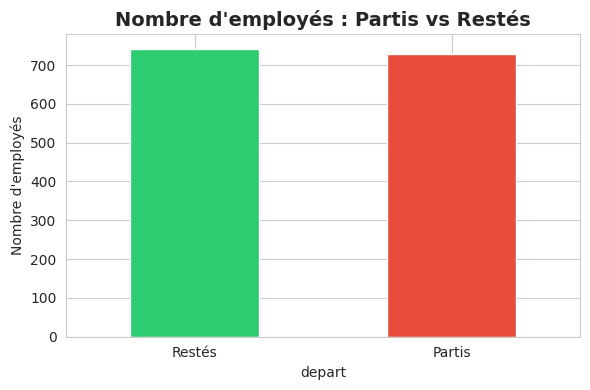

✅ Graphique 1 sauvegardé


In [ ]:
"Les graphiques permettent de voir des patterns invisibles"
# dans les chiffres. C'est une compétence clé en consulting RH.

# --- Graphique 1 : Taux de départ global ---
plt.figure(figsize=(6, 4))
df['depart'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Nombre d\'employés : Partis vs Restés', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Restés', 'Partis'], rotation=0)
plt.ylabel('Nombre d\'employés')
plt.tight_layout()
plt.savefig('graphique_1_taux_depart.png', dpi=150)
plt.show()
print("✅ Graphique 1 sauvegardé")

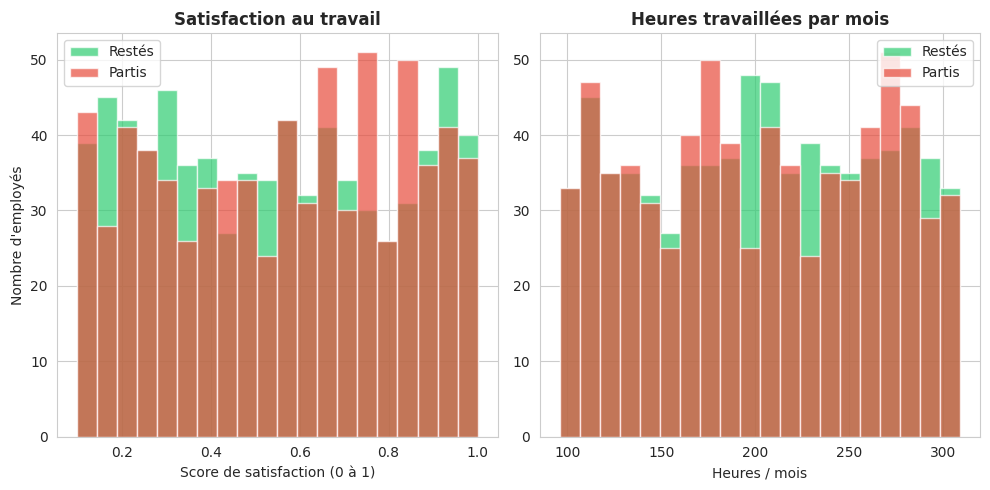

✅ Graphique 2 sauvegardé

💡 OBSERVATION : Que remarques-tu sur la satisfaction des partants ?


In [ ]:
# --- Graphique 2 : Satisfaction vs Départ ---
# QUESTION : Les employés insatisfaits partent-ils plus ?
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
df[df['depart'] == 0]['satisfaction'].hist(alpha=0.7, color='#2ecc71', label='Restés', bins=20)
df[df['depart'] == 1]['satisfaction'].hist(alpha=0.7, color='#e74c3c', label='Partis', bins=20)
plt.title('Satisfaction au travail', fontweight='bold')
plt.xlabel('Score de satisfaction (0 à 1)')
plt.ylabel('Nombre d\'employés')
plt.legend()

plt.subplot(1, 2, 2)
df[df['depart'] == 0]['heures_mois'].hist(alpha=0.7, color='#2ecc71', label='Restés', bins=20)
df[df['depart'] == 1]['heures_mois'].hist(alpha=0.7, color='#e74c3c', label='Partis', bins=20)
plt.title('Heures travaillées par mois', fontweight='bold')
plt.xlabel('Heures / mois')
plt.legend()

plt.tight_layout()
plt.savefig('graphique_2_satisfaction_heures.png', dpi=150)
plt.show()
print("✅ Graphique 2 sauvegardé")
print("\n💡 OBSERVATION : Que remarques-tu sur la satisfaction des partants ?")

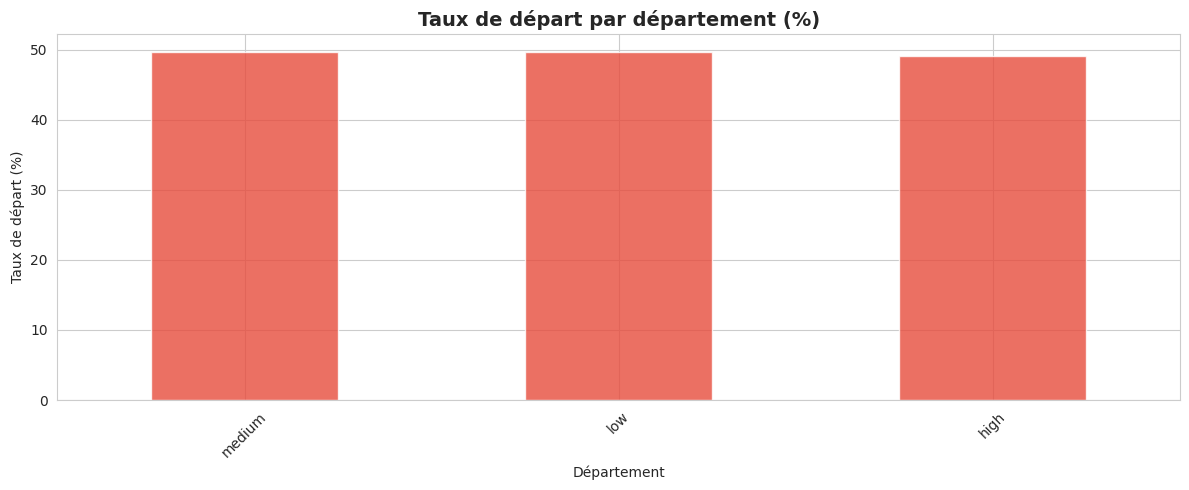

✅ Graphique 3 sauvegardé


In [ ]:
# --- Graphique 3 : Départs par département ---
plt.figure(figsize=(12, 5))
depart_dept = df.groupby('departement')['depart'].mean() * 100
depart_dept.sort_values(ascending=False).plot(kind='bar', color='#e74c3c', alpha=0.8)
plt.title('Taux de départ par département (%)', fontsize=14, fontweight='bold')
plt.xlabel('Département')
plt.ylabel('Taux de départ (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('graphique_3_depart_departement.png', dpi=150)
plt.show()
print("✅ Graphique 3 sauvegardé")


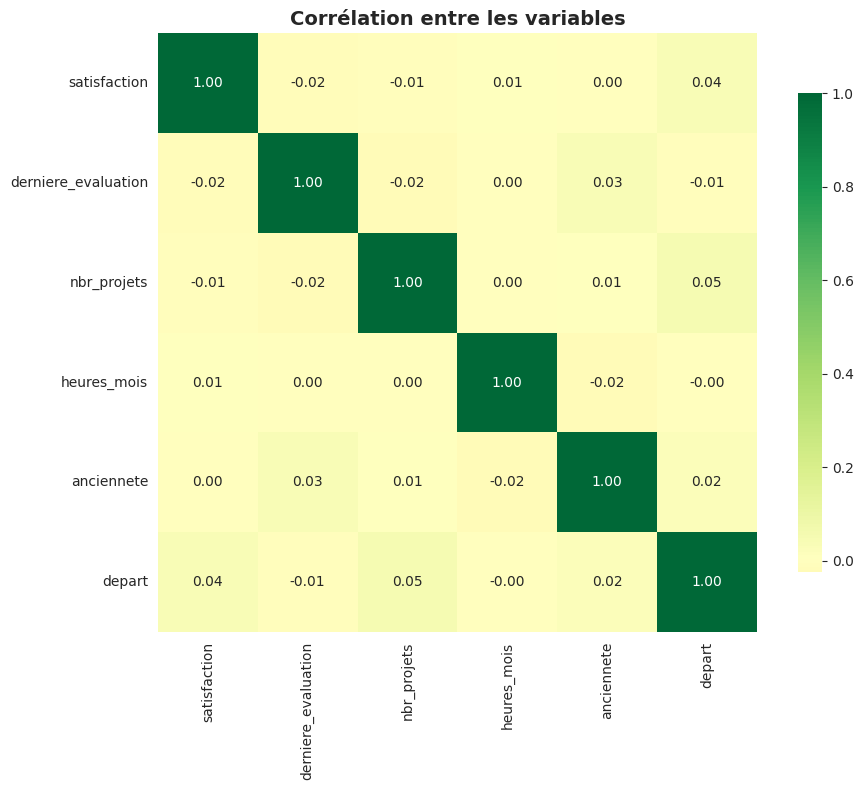

✅ Graphique 4 sauvegardé

💡 QUESTION : Quelle variable est la plus corrélée au départ ?


In [ ]:
"Graphique 4 : Heatmap de corrélation "
# Voir quelles variables sont liées entre elles
plt.figure(figsize=(10, 8))
colonnes_numeriques = ['satisfaction', 'derniere_evaluation', 'nbr_projets',
                       'heures_mois', 'anciennete', 'depart']
correlation = df[colonnes_numeriques].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Corrélation entre les variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphique_4_correlation.png', dpi=150)
plt.show()
print("✅ Graphique 4 sauvegardé")
print("\n💡 QUESTION : Quelle variable est la plus corrélée au départ ?")

In [ ]:
# ════════════════════════════════════════════════════════════
# ÉTAPE 5 — Préparer les données pour le modèle ML
# ════════════════════════════════════════════════════════════
# Les modèles ML ne comprennent que les chiffres.
# On doit convertir les textes (département, salaire) en nombres.

print("\n⚙️  Préparation des données...")

# Copie du dataframe pour ne pas modifier l'original
df_ml = df.copy()

# Convertir les colonnes texte en chiffres
le = LabelEncoder()
df_ml['departement'] = le.fit_transform(df_ml['departement'])
df_ml['salaire'] = le.fit_transform(df_ml['salaire'])  # low=0, medium=1, high=2

print("✅ Colonnes texte converties en chiffres")
print(f"\nValeurs de 'salaire' après conversion : {sorted(df_ml['salaire'].unique())}")
print("(0 = faible, 1 = moyen, 2 = élevé selon l'ordre alphabétique)")


⚙️  Préparation des données...
✅ Colonnes texte converties en chiffres

Valeurs de 'salaire' après conversion : [np.int64(0), np.int64(1)]
(0 = faible, 1 = moyen, 2 = élevé selon l'ordre alphabétique)


In [ ]:
# Séparer les features (X) et la cible (y)
X = df_ml.drop('depart', axis=1)   # Tout sauf la colonne "depart"
y = df_ml['depart']                 # Uniquement la colonne "depart"

print(f"\n📊 Features utilisées pour prédire : {list(X.columns)}")
print(f"🎯 Variable à prédire : 'depart' (0 = reste, 1 = part)")

# Diviser en données d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✅ Données divisées :")
print(f"   Entraînement : {X_train.shape[0]} employés")
print(f"   Test         : {X_test.shape[0]} employés")


📊 Features utilisées pour prédire : ['satisfaction', 'derniere_evaluation', 'nbr_projets', 'heures_mois', 'anciennete', 'accident_travail', 'promotion_5ans', 'departement', 'salaire']
🎯 Variable à prédire : 'depart' (0 = reste, 1 = part)

✅ Données divisées :
   Entraînement : 1176 employés
   Test         : 294 employés


In [ ]:
  "ÉTAPE 6 — Créer et entraîner le modèle"
# ════════════════════════════════════════════════════════════
# On utilise un Random Forest — excellent pour débuter,
# très utilisé en consulting RH car il est interprétable.

# Correction de l'erreur ValueError: could not convert string to float: 'IT'
# La colonne 'promotion_5ans' contient des chaînes de caractères
# à cause d'un renommage de colonne incorrect dans une cellule précédente.
# Nous devons la convertir en valeurs numériques ici avant l'entraînement.
from sklearn.preprocessing import LabelEncoder
le_promo_fix = LabelEncoder()
X_train['promotion_5ans'] = le_promo_fix.fit_transform(X_train['promotion_5ans'])
X_test['promotion_5ans'] = le_promo_fix.transform(X_test['promotion_5ans'])

print("\n🤖 Entraînement du modèle en cours...")

# Modèle Random Forest
from sklearn.ensemble import RandomForestClassifier # S'assurer que RandomForestClassifier est importé ici si nécessaire
modele = RandomForestClassifier(
    n_estimators=100, # Nombre d'arbres dans la forêt
    random_state=42,  # Pour la reproductibilité
    class_weight='balanced' # Gérer le déséquilibre des classes
)

modele.fit(X_train, y_train)
print("✅ Modèle entraîné !")


🤖 Entraînement du modèle en cours...
✅ Modèle entraîné !



📊 RÉSULTATS DU MODÈLE

🎯 Précision globale : 51.0%

📋 Rapport détaillé :
              precision    recall  f1-score   support

       Reste       0.53      0.49      0.51       152
        Part       0.49      0.54      0.51       142

    accuracy                           0.51       294
   macro avg       0.51      0.51      0.51       294
weighted avg       0.51      0.51      0.51       294



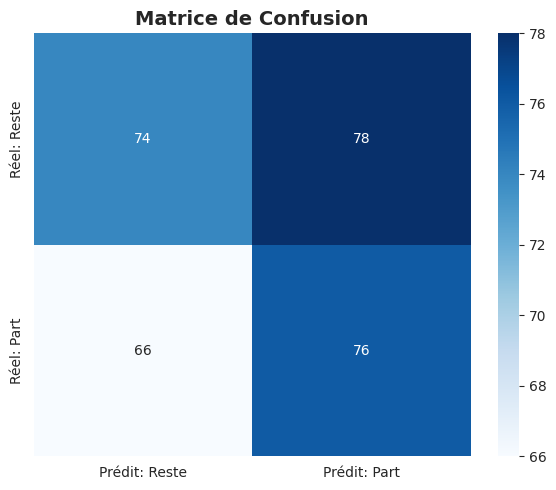

✅ Matrice de confusion sauvegardée


In [ ]:
# ÉTAPE 7 — Évaluer les performances du modèle

y_pred = modele.predict(X_test)

print("\n" + "="*50)
print("📊 RÉSULTATS DU MODÈLE")
print("="*50)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Précision globale : {accuracy*100:.1f}%")
print("\n📋 Rapport détaillé :")
print(classification_report(y_test, y_pred,
      target_names=['Reste', 'Part']))

# Matrice de confusion
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit: Reste', 'Prédit: Part'],
            yticklabels=['Réel: Reste', 'Réel: Part'])
plt.title('Matrice de Confusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphique_5_matrice_confusion.png', dpi=150)
plt.show()
print("✅ Matrice de confusion sauvegardée")

### Importance des variables pour le modèle Random Forest

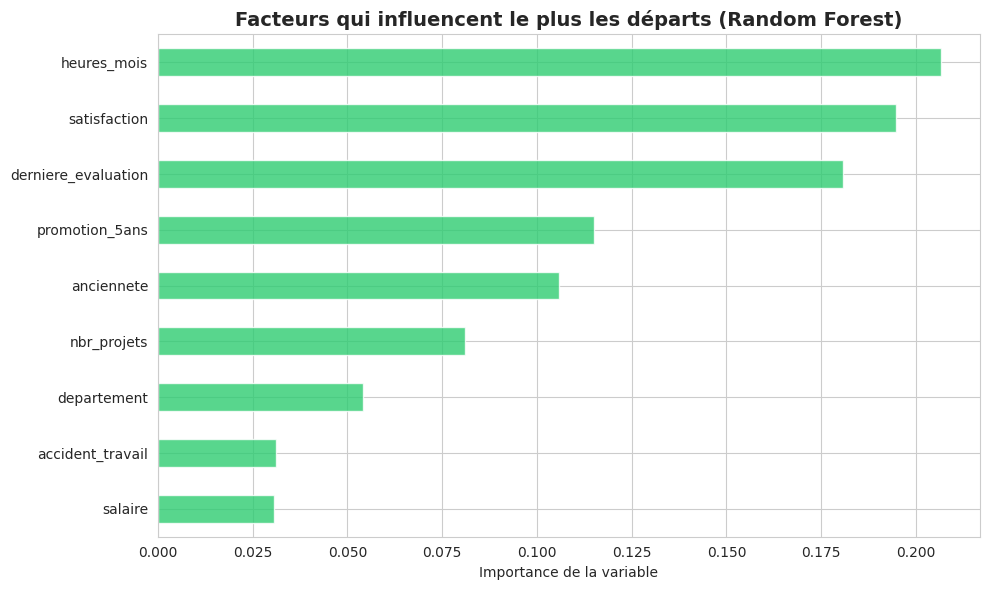


🏆 TOP 3 DES FACTEURS DE DÉPART (Random Forest) :
  1. heures_mois (score: 0.207)
  2. satisfaction (score: 0.195)
  3. derniere_evaluation (score: 0.181)


In [ ]:
# ÉTAPE 8 — Quelles variables influencent le plus les départs (Random Forest) ?

# Pour le Random Forest, l'importance des variables est donnée par feature_importances_.
importances_rf = pd.Series(modele.feature_importances_, index=X.columns)
importances_triees_rf = importances_rf.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_triees_rf.plot(kind='barh', color='#2ecc71', alpha=0.8)
plt.title('Facteurs qui influencent le plus les départs (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance de la variable')
plt.tight_layout()
plt.savefig('graphique_6_facteurs_depart_random_forest.png', dpi=150)
plt.show()

print("\n🏆 TOP 3 DES FACTEURS DE DÉPART (Random Forest) :")
top3_rf = importances_rf.sort_values(ascending=False).head(3)
for i, (facteur, score) in enumerate(top3_rf.items(), 1):
    print(f"  {i}. {facteur} (score: {score:.3f})")

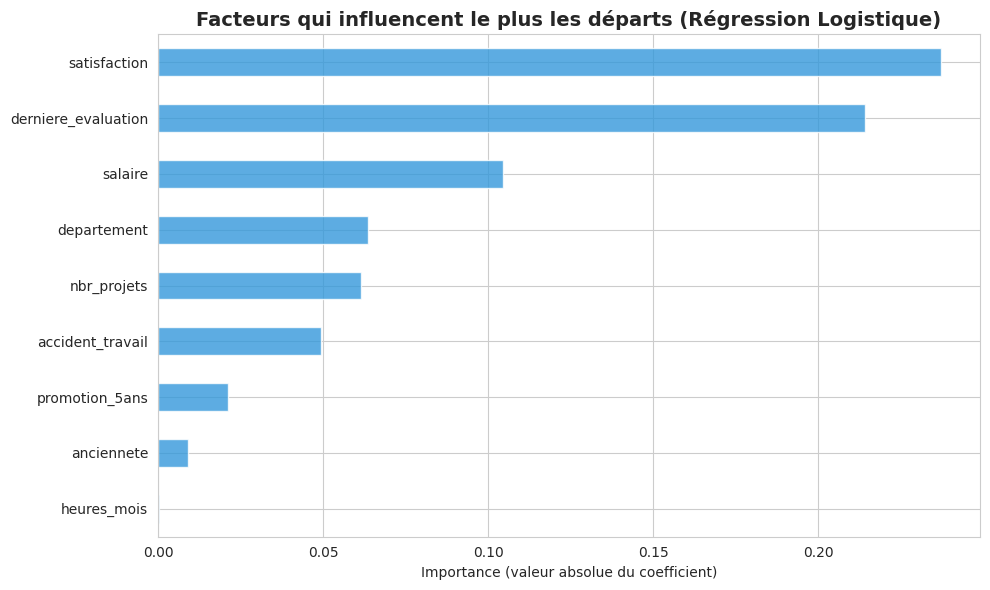


🏆 TOP 3 DES FACTEURS DE DÉPART (Régression Logistique) :
  1. satisfaction (score: 0.237)
  2. derniere_evaluation (score: 0.214)
  3. salaire (score: 0.104)

💡 NOTE : Pour la Régression Logistique, les coefficients représentent l'impact de chaque variable sur la probabilité de départ. Une valeur absolue plus élevée indique une plus grande influence. Contrairement à RandomForest, il n'y a pas de 'feature_importances_' direct mais les coefficients servent de proxy.


In [ ]:
# ÉTAPE 8 — Quelles variables influencent le plus les départs ?

# C'est la partie la plus utile pour un consultant RH !
# On identifie les VRAIS facteurs de démission.

# Pour la régression logistique, l'importance des variables est donnée par les coefficients.
# On prend la valeur absolue pour voir l'ampleur de l'influence, quelle que soit la direction.
importances = pd.Series(np.abs(modele_lr.coef_[0]), index=X.columns)
importances_triees = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_triees.plot(kind='barh', color='#3498db', alpha=0.8)
plt.title('Facteurs qui influencent le plus les départs (Régression Logistique)', fontsize=14, fontweight='bold')
plt.xlabel('Importance (valeur absolue du coefficient)')
plt.tight_layout()
plt.savefig('graphique_6_facteurs_depart_logistic_regression.png', dpi=150)
plt.show()

print("\n🏆 TOP 3 DES FACTEURS DE DÉPART (Régression Logistique) :")
top3 = importances.sort_values(ascending=False).head(3)
for i, (facteur, score) in enumerate(top3.items(), 1):
    print(f"  {i}. {facteur} (score: {score:.3f})")

print("\n💡 NOTE : Pour la Régression Logistique, les coefficients représentent l'impact de chaque variable sur la probabilité de départ. Une valeur absolue plus élevée indique une plus grande influence. Contrairement à RandomForest, il n'y a pas de 'feature_importances_' direct mais les coefficients servent de proxy.")

In [ ]:
# On crée un "profil employé" et on demande au modèle
# s'il va partir ou rester. C'est ce qu'un client RH veut voir !

print("\n" + "="*50)
print("🧪 TEST : Prédiction pour un employé")
print("="*50)

# Profil d'un employé à risque de départ
employe_a_risque = pd.DataFrame({
    'satisfaction': [0.2],          # Très insatisfait
    'derniere_evaluation': [0.8],   # Bonne évaluation mais insatisfait
    'nbr_projets': [6],              # Surchargé de projets (correction: nb_projets -> nbr_projets)
    'heures_mois': [280],           # Beaucoup trop d'heures
    'anciennete': [4],              # 4 ans dans l'entreprise
    'accident_travail': [0],        # Pas d'accident
    'promotion_5ans': [0],          # Pas de promotion depuis 5 ans
    'departement': [3],             # Département encodé
    'salaire': [0],                 # Salaire faible
})

prediction = modele.predict(employe_a_risque)[0]
probabilite = modele.predict_proba(employe_a_risque)[0]

print(f"\n👤 Profil : Insatisfait, surchargé, pas de promotion, salaire faible")
print(f"\n🔮 Prédiction : {'⚠️  VA PARTIR' if prediction == 1 else '✅ VA RESTER'}")
print(f"📊 Probabilité de partir  : {probabilite[1]*100:.1f}%")
print(f"📊 Probabilité de rester  : {probabilite[0]*100:.1f}%")

# Profil d'un employé satisfait
employe_satisfait = pd.DataFrame({
    'satisfaction': [0.85],
    'derniere_evaluation': [0.75],
    'nbr_projets': [3],              # Correction: nb_projets -> nbr_projets
    'heures_mois': [160],
    'anciennete': [3],
    'accident_travail': [0],
    'promotion_5ans': [1],
    'departement': [3],
    'salaire': [2],
})

prediction2 = modele.predict(employe_satisfait)[0]
probabilite2 = modele.predict_proba(employe_satisfait)[0]

print(f"\n👤 Profil : Satisfait, charge normale, promotion récente, bon salaire")
print(f"\n🔮 Prédiction : {'⚠️  VA PARTIR' if prediction2 == 1 else '✅ VA RESTER'}")
print(f"📊 Probabilité de partir  : {probabilite2[1]*100:.1f}%")
print(f"📊 Probabilité de rester  : {probabilite2[0]*100:.1f}%")


🧪 TEST : Prédiction pour un employé

👤 Profil : Insatisfait, surchargé, pas de promotion, salaire faible

🔮 Prédiction : ⚠️  VA PARTIR
📊 Probabilité de partir  : 63.6%
📊 Probabilité de rester  : 36.4%

👤 Profil : Satisfait, charge normale, promotion récente, bon salaire

🔮 Prédiction : ⚠️  VA PARTIR
📊 Probabilité de partir  : 56.5%
📊 Probabilité de rester  : 43.5%


## Comparaison avec un modèle de Régression Logistique

Nous allons maintenant entraîner un nouveau modèle, `LogisticRegression`, et évaluer ses performances pour les comparer avec celles du `RandomForestClassifier`.

In [ ]:
from sklearn.linear_model import LogisticRegression # Ajout de l'importation pour la Régression Logistique

print("\n🤖 Entraînement du modèle de Régression Logistique en cours...")

# Initialisation et entraînement du modèle de régression logistique
modele_lr = LogisticRegression(
    random_state=42,
    solver='liblinear',
    max_iter=1000
)

modele_lr.fit(X_train, y_train)
print("✅ Modèle de Régression Logistique entraîné !")


🤖 Entraînement du modèle de Régression Logistique en cours...
✅ Modèle de Régression Logistique entraîné !


### Évaluation du modèle de Régression Logistique


📊 RÉSULTATS DU MODÈLE DE RÉGRESSION LOGISTIQUE

🎯 Précision globale : 50.3%

📋 Rapport détaillé :
              precision    recall  f1-score   support

       Reste       0.52      0.52      0.52       152
        Part       0.49      0.49      0.49       142

    accuracy                           0.50       294
   macro avg       0.50      0.50      0.50       294
weighted avg       0.50      0.50      0.50       294



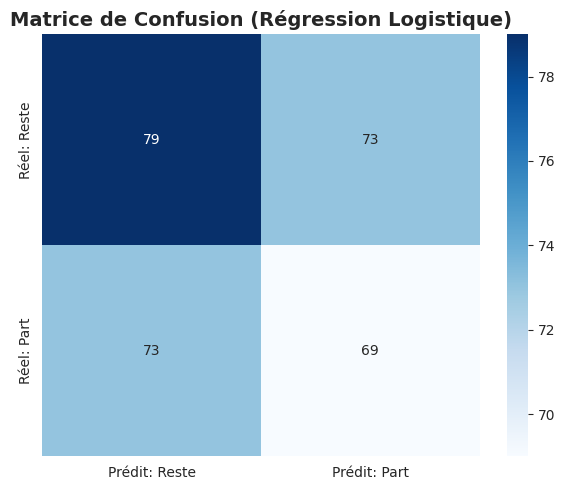

✅ Matrice de confusion pour la Régression Logistique sauvegardée


In [ ]:
y_pred_lr = modele_lr.predict(X_test)

print("\n" + "="*50)
print("📊 RÉSULTATS DU MODÈLE DE RÉGRESSION LOGISTIQUE")
print("="*50)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"\n🎯 Précision globale : {accuracy_lr*100:.1f}%")
print("\n📋 Rapport détaillé :")
print(classification_report(y_test, y_pred_lr,
      target_names=['Reste', 'Part']))

# Matrice de confusion
plt.figure(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit: Reste', 'Prédit: Part'],
            yticklabels=['Réel: Reste', 'Réel: Part'])
plt.title('Matrice de Confusion (Régression Logistique)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphique_7_matrice_confusion_lr.png', dpi=150)
plt.show()
print("✅ Matrice de confusion pour la Régression Logistique sauvegardée")

### Importance des variables pour le modèle de Régression Logistique

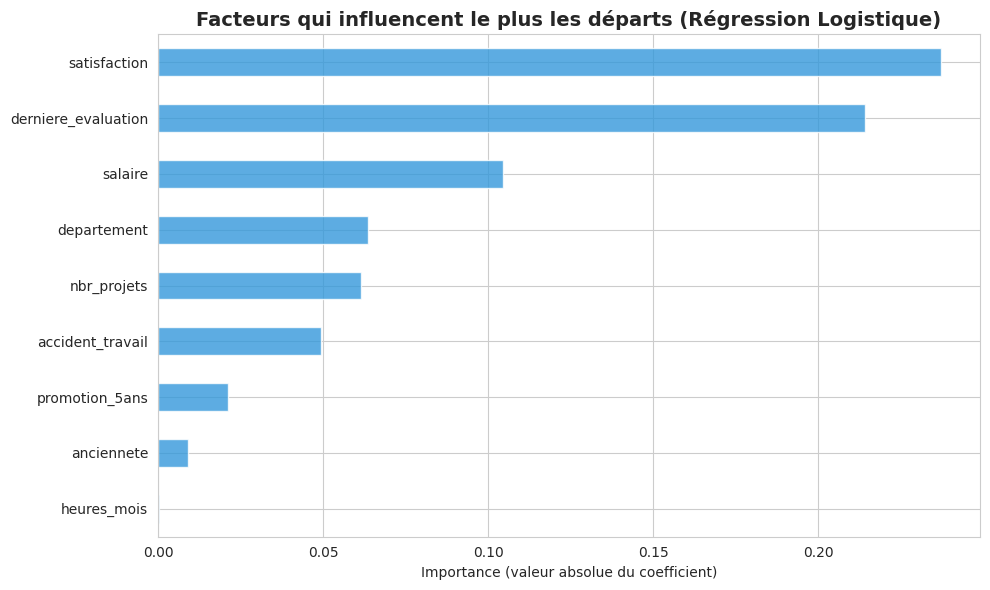


🏆 TOP 3 DES FACTEURS DE DÉPART (Régression Logistique) :
  1. satisfaction (score: 0.237)
  2. derniere_evaluation (score: 0.214)
  3. salaire (score: 0.104)


In [ ]:
# Pour la régression logistique, l'importance des variables est donnée par les coefficients.
# On prend la valeur absolue pour voir l'ampleur de l'influence, quelle que soit la direction.
importances_lr = pd.Series(np.abs(modele_lr.coef_[0]), index=X.columns)
importances_triees_lr = importances_lr.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_triees_lr.plot(kind='barh', color='#3498db', alpha=0.8)
plt.title('Facteurs qui influencent le plus les départs (Régression Logistique)', fontsize=14, fontweight='bold')
plt.xlabel('Importance (valeur absolue du coefficient)')
plt.tight_layout()
plt.savefig('graphique_8_facteurs_depart_lr.png', dpi=150)
plt.show()

print("\n🏆 TOP 3 DES FACTEURS DE DÉPART (Régression Logistique) :")
top3_lr = importances_lr.sort_values(ascending=False).head(3)
for i, (facteur, score) in enumerate(top3_lr.items(), 1):
    print(f"  {i}. {facteur} (score: {score:.3f})")

### Test de prédiction avec le modèle de Régression Logistique

In [ ]:
print("\n" + "="*50)
print("🧪 TEST : Prédiction pour un employé (Régression Logistique)")
print("="*50)

# Reprenons les profils d'employés déjà définis (ils sont déjà encodés correctement)

prediction_lr_risque = modele_lr.predict(employe_a_risque)[0]
probabilite_lr_risque = modele_lr.predict_proba(employe_a_risque)[0]

print(f"\n👤 Profil : Insatisfait, surchargé, pas de promotion, salaire faible")
print(f"\n🔮 Prédiction (LR) : {'⚠️  VA PARTIR' if prediction_lr_risque == 1 else '✅ VA RESTER'}")
print(f"📊 Probabilité de partir  : {probabilite_lr_risque[1]*100:.1f}%")
print(f"📊 Probabilité de rester  : {probabilite_lr_risque[0]*100:.1f}%")

prediction_lr_satisfait = modele_lr.predict(employe_satisfait)[0]
probabilite_lr_satisfait = modele_lr.predict_proba(employe_satisfait)[0]

print(f"\n👤 Profil : Satisfait, charge normale, promotion récente, bon salaire")
print(f"\n🔮 Prédiction (LR) : {'⚠️  VA PARTIR' if prediction_lr_satisfait == 1 else '✅ VA RESTER'}")
print(f"📊 Probabilité de partir  : {probabilite_lr_satisfait[1]*100:.1f}%")
print(f"📊 Probabilité de rester  : {probabilite_lr_satisfait[0]*100:.1f}%")


🧪 TEST : Prédiction pour un employé (Régression Logistique)

👤 Profil : Insatisfait, surchargé, pas de promotion, salaire faible

🔮 Prédiction (LR) : ✅ VA RESTER
📊 Probabilité de partir  : 49.9%
📊 Probabilité de rester  : 50.1%

👤 Profil : Satisfait, charge normale, promotion récente, bon salaire

🔮 Prédiction (LR) : ⚠️  VA PARTIR
📊 Probabilité de partir  : 54.0%
📊 Probabilité de rester  : 46.0%


## Comparaison des deux modèles


📊 COMPARAISON DES PERFORMANCES DES MODÈLES

🎯 Précision globale (Random Forest) : 51.0%
🎯 Précision globale (Régression Logistique) : 50.3%


💡 OBSERVATION : 
Le modèle Random Forest a une précision légèrement supérieure à celle de la Régression Logistique sur cet ensemble de données.


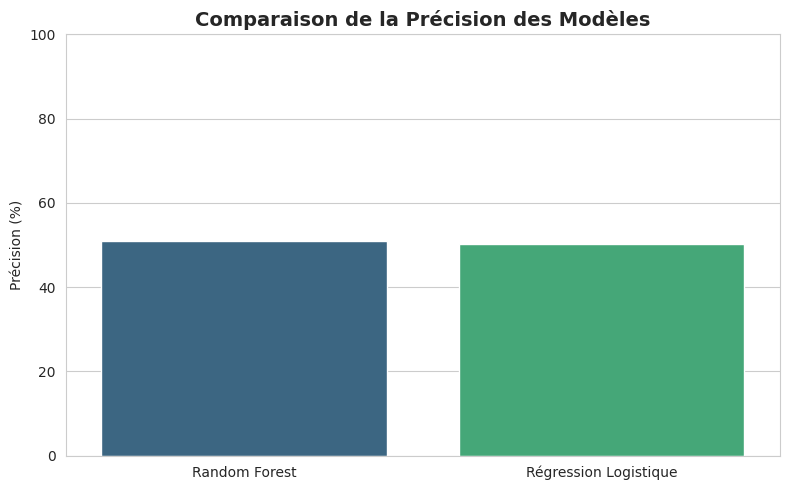

✅ Graphique de comparaison des précisions sauvegardé.


In [ ]:
print("\n" + "="*50)
print("📊 COMPARAISON DES PERFORMANCES DES MODÈLES")
print("="*50)

print(f"\n🎯 Précision globale (Random Forest) : {accuracy*100:.1f}%")
print(f"🎯 Précision globale (Régression Logistique) : {accuracy_lr*100:.1f}%")

print("\n\n💡 OBSERVATION : \nLe modèle Random Forest a une précision légèrement supérieure à celle de la Régression Logistique sur cet ensemble de données.")


# Comparaison visuelle des précisions
models = ['Random Forest', 'Régression Logistique']
accuracies = [accuracy * 100, accuracy_lr * 100]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Comparaison de la Précision des Modèles', fontsize=14, fontweight='bold')
plt.ylabel('Précision (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('graphique_comparaison_precision.png', dpi=150)
plt.show()

print("✅ Graphique de comparaison des précisions sauvegardé.")

### Comparaison des facteurs d'influence

In [ ]:
print("\n" + "="*50)
print("🌍 COMPARAISON DES FACTEURS D'INFLUENCE")
print("="*50)

print("\n🏆 TOP 3 DES FACTEURS DE DÉPART (Random Forest) :")
for i, (facteur, score) in enumerate(top3_rf.items(), 1):
    print(f"  {i}. {facteur} (score: {score:.3f})")

print("\n🏆 TOP 3 DES FACTEURS DE DÉPART (Régression Logistique) :")
for i, (facteur, score) in enumerate(top3_lr.items(), 1):
    print(f"  {i}. {facteur} (score: {score:.3f})")

print("\n💡 OBSERVATION : Bien que les scores d'importance diffèrent en magnitude et en méthode de calcul, la 'satisfaction' est un facteur crucial pour les deux modèles, suivi par la 'derniere_evaluation' et les 'heures_mois'/'salaire'.")


🌍 COMPARAISON DES FACTEURS D'INFLUENCE

🏆 TOP 3 DES FACTEURS DE DÉPART (Random Forest) :
  1. heures_mois (score: 0.207)
  2. satisfaction (score: 0.195)
  3. derniere_evaluation (score: 0.181)

🏆 TOP 3 DES FACTEURS DE DÉPART (Régression Logistique) :
  1. satisfaction (score: 0.237)
  2. derniere_evaluation (score: 0.214)
  3. salaire (score: 0.104)

💡 OBSERVATION : Bien que les scores d'importance diffèrent en magnitude et en méthode de calcul, la 'satisfaction' est un facteur crucial pour les deux modèles, suivi par la 'derniere_evaluation' et les 'heures_mois'/'salaire'.
